# Exploratory Data Analysis

This notebook examines the dataset from https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations. The goals of this notebook are:
1. Understand the structure and content of the dataset.
2. Identify any missing or inconsistent data.
3. Generate summary statistics and visualizations to uncover patterns and insights.

## Getting started

Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys
import chess
if ".." not in sys.path:
    sys.path.insert(0, '..')

from src.utils import batch_fen_to_tensor

Loading the dataset

In [10]:
# not reading full 16M+ dataset
# df = pd.read_csv("../dataset/raw/chess_data.csv", nrows=100000)
df = pd.read_csv("../dataset/raw/random_evals.csv", nrows=100000)
# df = pd.read_csv("../dataset/raw/tactic_evals.csv", nrows=100000)

Basic info

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   FEN         100000 non-null  object
 1   Evaluation  100000 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [16]:
df.sample(5)

,FEN,Evaluation
14225,rnb2knr/p1p4p/2q2pp1/3B4/3P4/1Q2BN2/P1P2PPP/1R...,1455
25316,1R6/8/8/8/4K3/8/7p/7k b - - 1 76,0
11813,N3r3/pp4kp/2p2np1/8/2P1B1p1/5P2/PP2R1PP/6K1 b ...,113
66370,1q6/6bp/p5pk/1pQ2p2/8/3P1r1P/P5P1/1R4K1 w - - ...,-155
60102,rnbqk2r/pp1pbppp/4pn2/2p5/4PB2/3P1Q2/PPP2PPP/R...,-182


Turning `Evaluation` column to `int`

In [17]:
df = df[~df["Evaluation"].str.contains("#")]

AttributeError: Can only use .str accessor with string values!

In [18]:
df["Evaluation"] = df["Evaluation"].astype(int)
df.sample(5)

,FEN,Evaluation
11572,4r3/pp4kp/2p3p1/3N2pn/8/3B4/PPP2PPP/4R1K1 b - ...,-896
99514,rn3rk1/p4pbp/1q2p1p1/3pP3/4n3/2N3P1/PPPB1PKP/R...,-175
84532,r1bqr1k1/pppp1p1p/2n2n2/2b1p1p1/3PP3/1P5P/PBP1...,466
90419,rn1qk2r/pppbbppp/4pn2/3p4/3P4/1P4P1/PBP1PPBP/R...,67
48504,kr6/pb5p/2pq2p1/3p4/4R3/P1Q5/1PP2PPP/2K1R3 b -...,-378


In [19]:
df.describe()

,Evaluation
count,95139.000000
mean,12.103165
std,965.020171
min,-12783.000000
25%,-344.000000
50%,0.000000
75%,366.000000
max,9165.000000


Plotting the distribution of `Evaluation`

<Axes: ylabel='Frequency'>

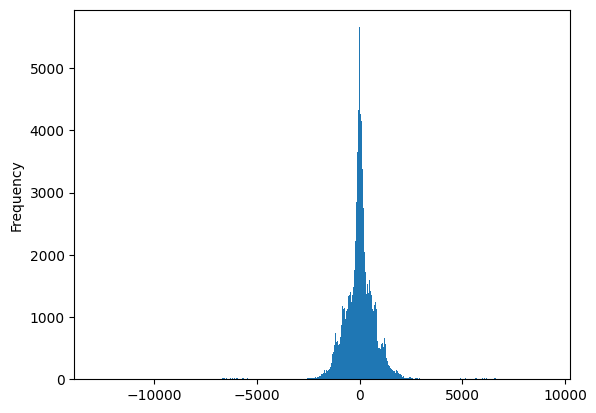

In [15]:
df['Evaluation'].plot.hist(bins=500)

Examining `FEN` column

In [20]:
df.sample(5)["FEN"].values

array(['r1bq1rk1/p3ppbp/1n1p2p1/3Pn3/2P5/2B2N2/1P2BPPP/RN1Q1K1R b - - 2 14',
       '2rqr1k1/p4pb1/6pp/8/PBPp4/3N4/1P1Q1PPP/1R3RK1 b - - 3 22',
       'r1b1r1k1/2qn1pbp/1p1p1np1/pPp1p1B1/P1PP4/2N1PN1P/4BPP1/RQ3RK1 b - - 1 14',
       'r1bq1rk1/3np1bp/pn1p2p1/1ppP1p2/4P3/2P2N1P/PPB2PP1/1RBQRNK1 w - - 0 15',
       'r1b1kb1r/p2ppppp/5n2/q1pN4/1p2P3/1n1P4/PPP1QPPP/R1B1K1NR b KQkq - 1 9'],
      dtype=object)

Converting `FEN` notation to suitable **tensor**

We’ll use this fixed order:

|Board #|Description|
|:-:|:-:|
|0|white pawn|
|1|white knight|
|2|white bishop|
|3|white rook|
|4|white queen|
|5|white king|
|6|black pawn|
|7|black knight|
|8|black bishop|
|9|black rook|
|10|black queen|
|11|black king|
|12|side to move (white=1, black=0)|
|13|white king-side castling|
|14|white queen-side castling|
|15|black king-side castling|
|16|black queen-side castling|
|17|en passant square|

In [21]:
samplee = df.sample().values[0]
samplee

array(['r7/6kp/5R2/1p2b1p1/1P1p1p2/PB1K1P1P/5P2/8 b - - 5 34', -797],
      dtype=object)

In [22]:
planes = batch_fen_to_tensor([samplee[0]])[0]
planes

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 1., 0., 1.],
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0., 

In [23]:
def plot_planes(planes: torch.Tensor = planes) -> None:
    plane_names = [
        "white pawn",
        "white knight",
        "white bishop",
        "white rook",
        "white queen",
        "white king",
        "black pawn",
        "black knight",
        "black bishop",
        "black rook",
        "black queen",
        "black king",
        "side to move (white=1, black=0)",
        "white king-side castling",
        "white queen-side castling",
        "black king-side castling",
        "black queen-side castling",
        "en passant square"
    ]
    planes = planes.cpu().numpy()

    fig, axes = plt.subplots(3, 6, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(18):
        ax = axes[i]
        ax.imshow(planes[i], cmap="gray", vmin=0, vmax=1)
        ax.set_title(plane_names[i])
        ax.axis("off")

    plt.tight_layout()
    plt.show()

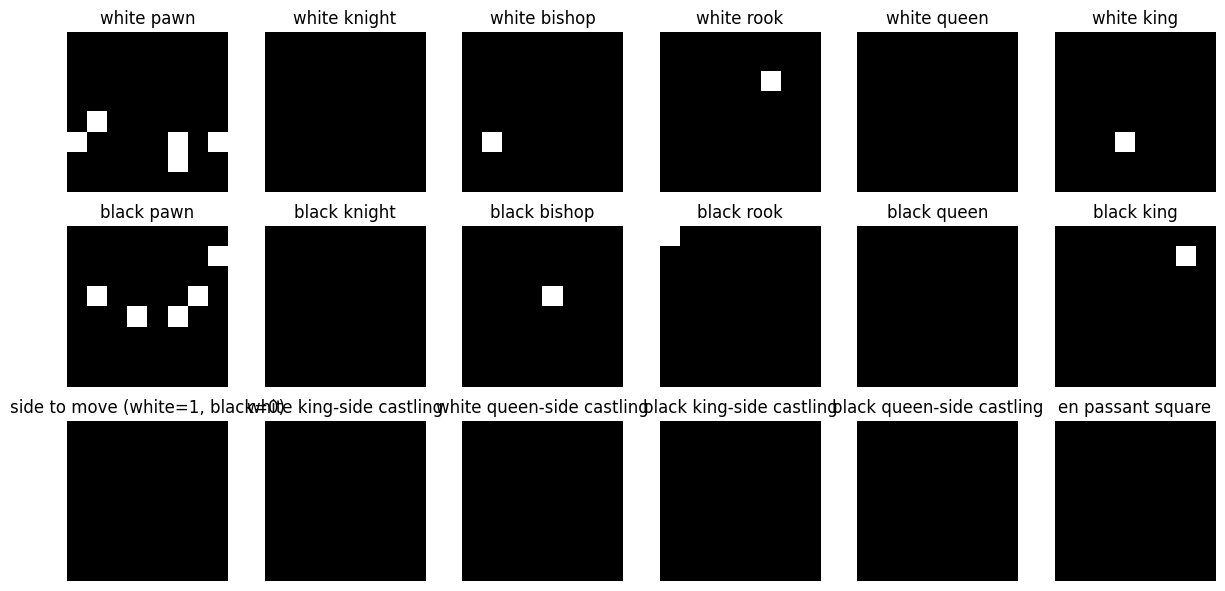

In [24]:
plot_planes(planes=planes)

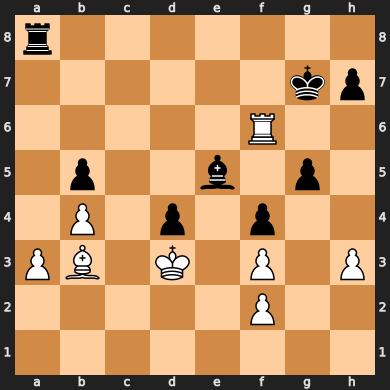

In [27]:
chess.Board(samplee[0])

In [28]:
print("Evaluation:", samplee[1])

Evaluation: -797


Examining outliers

In [34]:
position = df.sort_values(by="Evaluation", ascending=False).iloc[1]
position

FEN           rn2k1nr/p1p4p/4Bpp1/8/3P4/1Q2BN2/P1q2PPP/1R3RK...
Evaluation                                                 8958
Name: 14325, dtype: object

In [35]:
planes = batch_fen_to_tensor([position.iloc[0]])[0]
planes

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1., 

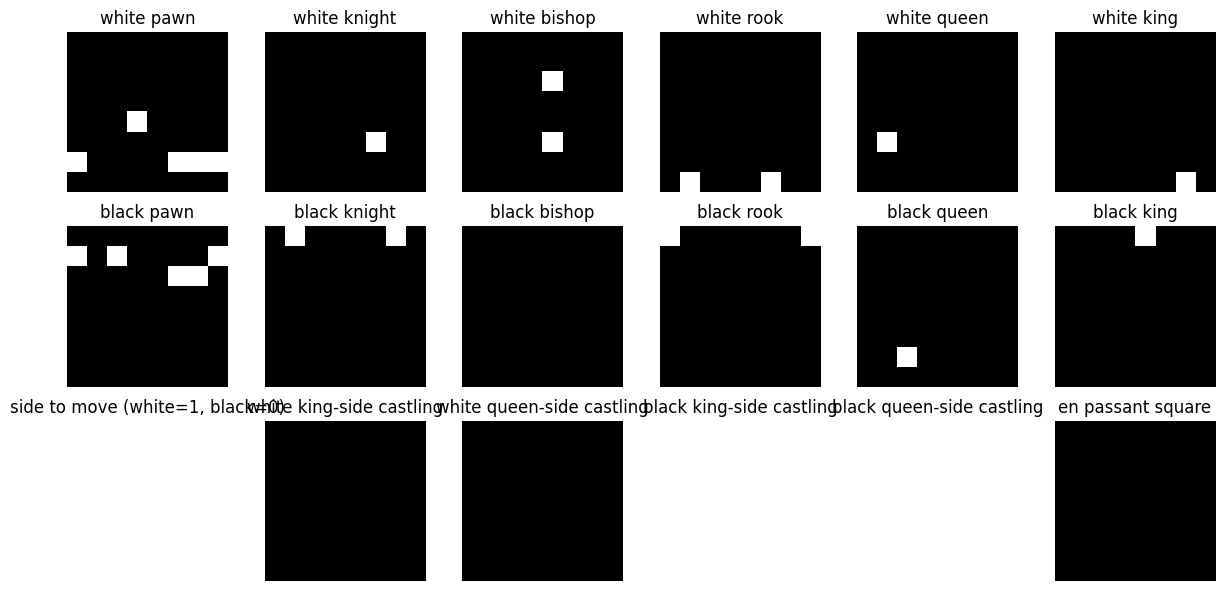

In [36]:
plot_planes(planes=planes)

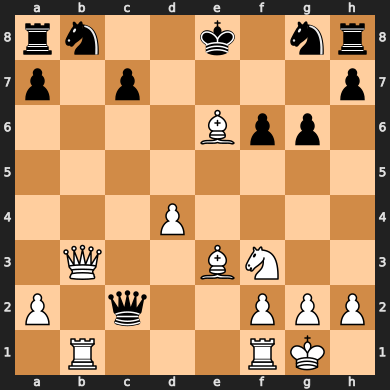

In [37]:
chess.Board(position.iloc[0])

In [38]:
print("Evaluation:", position.iloc[1])

Evaluation: 8958


## Examining `tactics_evals.csv`

This dataset contains positions primarily with tactics, hence there is more *moves-to-mate* positions

In [106]:
df = pd.read_csv("../dataset/raw/tactic_evals.csv", nrows=100_000)
df.sample(5)

,FEN,Evaluation,Move
30162,r2q1rk1/pp3pp1/1p1p1n1p/1P2p3/2B1P1b1/P2P1P2/2...,+540,f3g4
97484,5rk1/q4p1p/1n2p1p1/1B1pPn1P/3P4/1P3N2/P4PP1/R3...,-336,e1g1
21099,8/8/8/3p2p1/p2P4/P3n1k1/6P1/1rBK1R2 w - - 0 42,-1269,d1e2
90322,8/6k1/R4r1p/1pp2P2/8/P1P2P1P/2b5/6K1 w - - 0 32,-290,a6a7
51601,8/2p4p/3ppk2/2b1p3/Np2P2P/3P1P2/BPP5/2KR2r1 b ...,#-2,c5e3


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   FEN         100000 non-null  object
 1   Evaluation  100000 non-null  object
 2   Move        92990 non-null   object
dtypes: object(3)
memory usage: 2.3+ MB


Don't really need the `Move` column, so dropping it

In [108]:
df.drop(columns=["Move"], inplace=True)
df.sample(5)

,FEN,Evaluation
26101,r1b1kb1r/ppp2qp1/7p/8/1n2NP2/1P1PQN2/PBP1B2P/R...,-386
19877,r3r1k1/p4pbp/6p1/3p1P2/1q1P4/4QN2/P5PP/2R1R1K1...,+499
93286,8/2p1Nkpp/1p6/pn3r2/8/7P/5PP1/R5K1 w - - 2 33,+398
92547,8/8/p6p/P2n1p2/k4P2/5K2/7P/8 w - - 0 55,-1063
17794,4R3/1r1r3k/3p2pp/1p1R4/1PnB4/2P4P/p5P1/7K w - ...,#+1


Splitting evaluations into `df_cp` and `df_mtm` for evaluations in centipawns and moves-to-mate respectively

In [109]:
df_cp = df[~df["Evaluation"].str.contains("#")]
df_mtm = df[df["Evaluation"].str.contains("#")]

In [110]:
df_cp.sample(5)

,FEN,Evaluation
42989,2b1kb1r/3p1qp1/6r1/p1p1P2p/Pp1pN3/3P1Q2/1PP2PP...,-85
34543,8/4k3/1p2P2R/pr3P2/4K3/8/8/8 b - - 0 49,+143
37260,2k4r/pp4Q1/2p4p/3p4/3Pn3/B1P1q3/P5PP/R6K w - -...,+843
44313,8/8/1pk5/p7/1PP5/P2K4/8/8 b - - 0 48,+149
22610,R7/4kp2/p3b3/1p1pPp2/3P4/2P3P1/PP3PK1/8 b - - ...,+932


`df_cp` is the same as what we've seen before, so examining `df_mtm`

In [111]:
df_mtm.sample(5)

,FEN,Evaluation
8169,6k1/5pp1/2N1p2p/8/r7/3R1pP1/5P1P/6K1 b - - 1 35,#-2
91799,5r2/1b3p1k/r5p1/2pqB3/4pP2/PP2P1R1/6PP/R5K1 w ...,#+2
35,3N1k2/3R4/1r5p/4p1p1/5p2/2P5/2P2PPP/6K1 b - - ...,#-2
8488,r1b2rk1/pp3ppQ/2p5/6qp/3P4/4nPB1/P1B3PP/R4RK1 ...,#+0
83553,5r1k/1p5p/p2p4/2pPb3/P1P3N1/1P5P/6P1/5Q1K b - ...,#-1


In [112]:
df_mtm["Evaluation"].value_counts()

Evaluation
#-1     5182
#+1     5050
#-0     3532
#+0     3478
#-2     1787
#+2     1684
#-3      138
#+3      116
#+4        4
#-4        2
#+15       1
#+18       1
Name: count, dtype: int64

In [114]:
mate = df[df['Evaluation'] == "#+18"].sample().iloc[0]
mate

FEN           kr6/5Qp1/3q1b1p/1b1Bp3/p7/6P1/P4P1P/2R3K1 b - ...
Evaluation                                                 #+18
Name: 3867, dtype: object

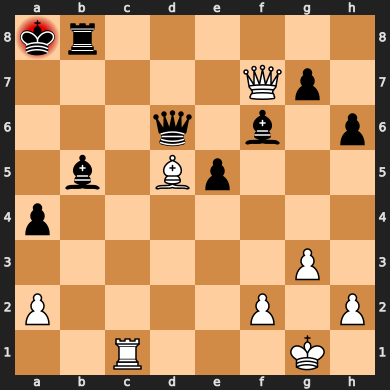

In [115]:
chess.Board(mate['FEN'])

In [117]:
df_mtm['Evaluation'].str.split("#").str[1].astype(int).max()

np.int64(18)

## Combining three dataframes into one

In [2]:
df1 = pd.read_csv("../dataset/raw/chess_data.csv", nrows=30000)
df2 = pd.read_csv("../dataset/raw/random_evals.csv", nrows=30000)
df3 = pd.read_csv("../dataset/raw/tactic_evals.csv", nrows=30000)

In [3]:
df = pd.concat([df1, df2, df3], ignore_index=True).drop(columns=['Move'])
df.head()

,FEN,Evaluation
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,+56
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,+52
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26


Normalizing `Evaluation` column values

In [15]:
df[df["Evaluation"].str.contains("#")]["Evaluation"]

59        #+6
60        #+6
61        #+4
62        #+3
1440     #-19
         ... 
89932     #-1
89943     #+2
89944     #+1
89946     #+1
89947     #+0
Name: Evaluation, Length: 8322, dtype: object

In [112]:
def normalize(
        x: str,
        minn: int, maxx: int
    ):

    num = int(x.split("#")[1])
    if num < 0:
        return -30_000 + 29_000 * np.abs(num / minn)
    elif num > 0:
        return 30_000 - 29_000 * (num / maxx)
    return int(x.split("#")[1][0] + "30000")

In [113]:
maxx = df[df["Evaluation"].str.contains("#")]["Evaluation"].str.split("#").str[1].astype(int).max()
minn = df[df["Evaluation"].str.contains("#")]["Evaluation"].str.split("#").str[1].astype(int).min()

In [114]:
minn

np.int64(-23)

In [115]:
maxx

np.int64(21)

In [116]:
df["Evaluation_norm"] = df["Evaluation"].apply(
    lambda x: normalize(
        x,
        minn,
        maxx
    ) if "#" in x else int(x)
).apply(lambda x: np.tanh(x / 500))

In [130]:
df[df['Evaluation'] == "#+19"].sample()

,FEN,Evaluation,Evaluation_norm
35948,rr6/pp3pk1/2pQ2p1/4pq2/8/2P2R2/5PP1/4R1K1 w - ...,#+19,0.999999


## Examining the preprocessed dataframe

In [4]:
df = pd.read_csv("../dataset/preprocessed/preprocessed.csv", nrows=None)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16586527 entries, 0 to 16586526
Data columns (total 2 columns):
 #   Column      Dtype  
---  ------      -----  
 0   FEN         object 
 1   Evaluation  float64
dtypes: float64(1), object(1)
memory usage: 253.1+ MB


In [6]:
df.Evaluation.describe()

count    1.658653e+07
mean     4.981651e-02
std      5.276831e-01
min     -1.000000e+00
25%     -2.392703e-01
50%      2.999100e-02
75%      3.833663e-01
max      1.000000e+00
Name: Evaluation, dtype: float64

<Axes: >

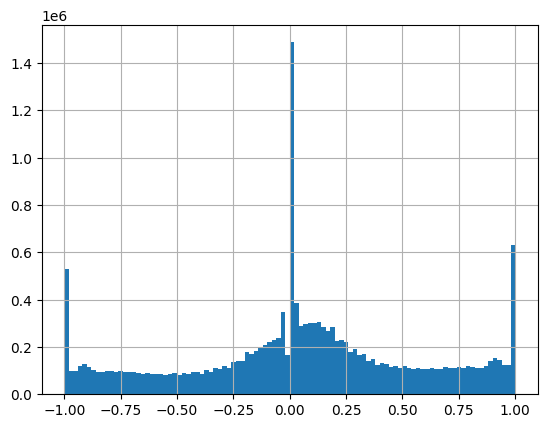

In [12]:
df.Evaluation.hist(bins=100)